## Notebook to learn to play with tif images

In [1]:
import sys
import random
import importlib as imp
import numpy as np
import matplotlib.pyplot as plt

import experiment_settings
import build_model
import train_model
import build_data
import methods
import read_landsat

import tensorflow as tf


In [2]:
print(f"python version = {sys.version}")
print(f"numpy version = {np.__version__}")
print(f"tensorflow version = {tf.__version__}")

# tf.config.set_visible_devices([], "GPU")  # turn-off tensorflow-metal if it is on
print(tf.config.list_physical_devices("GPU"))

python version = 3.10.10 | packaged by conda-forge | (main, Mar 24 2023, 20:12:31) [Clang 14.0.6 ]
numpy version = 1.23.2
tensorflow version = 2.10.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# GET SETTINGS
EXP_NAME = "exp1"
settings = experiment_settings.get_settings(EXP_NAME)
settings["mode"] = "training"
display(settings)

# SET RANDOM SEEDS
np.random.seed(settings["rng_seed"])
random.seed(settings["rng_seed"])
tf.random.set_seed(settings["rng_seed"])


{'mode': 'training',
 'training_years': (2015, 2016, 2017, 2018, 2019),
 'testing_years': (2020,),
 'latlon_bounds': (-7.999, -5.0, 105.0, 107.999),
 'channels': (1, 2, 3, 4, 5, 6),
 'nbatches': (500, 50),
 'scene_width': 114,
 'rng_seed': 33,
 'layers_units': (64, 128, 128, 128, 128),
 'kernel_size': 3,
 'max_pool_stride': (2, 2),
 'dense_units': 32,
 'kluge_value_for_zero': -0.2,
 'kluge_value_for_one': 1.2,
 'aug_randomflip': True,
 'input_noise': 10,
 'sample_weights_alpha': 25.0,
 'subsample': True,
 'learning_rate': 0.001,
 'dropout': 0.5,
 'patience': 3,
 'batch_size': 32,
 'max_epochs': 1000,
 'early_stopping': True,
 'pickup_where_leftoff': False,
 'save_best_only': True,
 'exp_name': 'exp1',
 'tile_len_deg': 1.0,
 'landsat_to_hfi_ratio': 10.0,
 'landsat_pixel_to_deg': 0.00026949}

In [4]:
# LOAD THE DATA
imp.reload(build_data)
imp.reload(methods)
imp.reload(read_landsat)

tags_train, tags_val = build_data.get_tags(settings)

tfds_train = build_data.build_tf_dataset(settings, tags_train, settings["batch_size"])
tfds_val = build_data.build_tf_dataset(settings, tags_val, settings["batch_size"])

batch_shape = np.shape(next(tfds_val.as_numpy_iterator())[0])
print(f"{batch_shape = }")


-8.0 -5.0 105.0 108.0
landsat_-7lat_105lon_2015
...frac_land.round(3) = 0.006, # samples = 128
landsat_-7lat_106lon_2015
...frac_land.round(3) = 0.282, # samples = 4992
landsat_-7lat_107lon_2015
...frac_land.round(3) = 0.615, # samples = 10848
landsat_-6lat_105lon_2015
...frac_land.round(3) = 0.422, # samples = 7424
landsat_-6lat_106lon_2015
...frac_land.round(3) = 0.969, # samples = 17088
landsat_-6lat_107lon_2015
...frac_land.round(3) = 0.913, # samples = 16064
landsat_-5lat_105lon_2015
...frac_land.round(3) = 0.744, # samples = 13120
landsat_-5lat_106lon_2015
...frac_land.round(3) = 0.129, # samples = 2304
landsat_-5lat_107lon_2015
...frac_land.round(3) = 0.029, # samples = 512

total training samples = 65696, total validation samples = 6784
len(tags[0]) = 65696
Metal device set to: Apple M1 Max

systemMemory: 64.00 GB
maxCacheSize: 24.00 GB

len(tags[0]) = 6784
batch_shape = (32, 114, 114, 6)


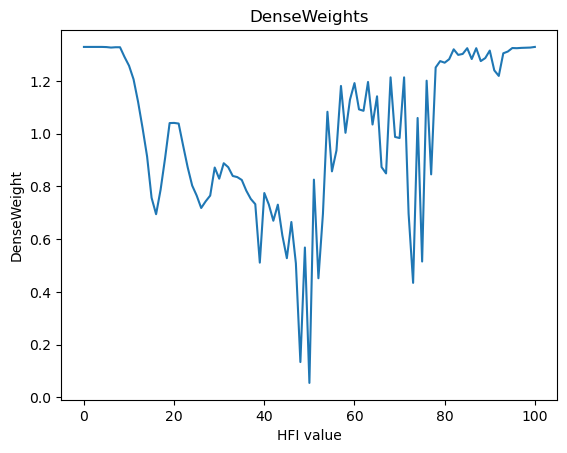

In [5]:
imp.reload(methods)
denseweights = methods.get_denseweights(settings, tags_train)

plt.title("DenseWeights")
plt.plot(np.arange(0, 101, 1), denseweights)
plt.xlabel("HFI value")
plt.ylabel("DenseWeight")
plt.show()

In [6]:
# TRAIN THE MODEL
imp.reload(build_model)
imp.reload(train_model)
imp.reload(methods)

tf.keras.backend.clear_session()
model = build_model.build_model(settings, input_shape=batch_shape[1:])

settings["mode"] = "training"
model, fit_summary, history, settings = train_model.train_model(
    settings, model, tfds_train, tfds_val, denseweights
)
fit_summary

Epoch 1/1000
2053/2053 [==============================] - 377s 183ms/step - loss: 10.0966 - mae: 8.0940 - val_loss: 10.4725 - val_mae: 7.9290 - lr: 0.0010
Epoch 2/1000
2053/2053 [==============================] - 394s 192ms/step - loss: 8.6109 - mae: 6.7910 - val_loss: 10.5930 - val_mae: 8.0345 - lr: 0.0010
Epoch 3/1000
2053/2053 [==============================] - 410s 199ms/step - loss: 8.2240 - mae: 6.5183 - val_loss: 10.3971 - val_mae: 7.8453 - lr: 0.0010
Epoch 4/1000
2053/2053 [==============================] - 422s 205ms/step - loss: 7.8633 - mae: 6.2398 - val_loss: 11.3106 - val_mae: 8.2289 - lr: 0.0010
Epoch 5/1000
2053/2053 [==============================] - 413s 201ms/step - loss: 7.5280 - mae: 6.0097 - val_loss: 11.3397 - val_mae: 8.4179 - lr: 0.0010
Epoch 6/1000
2053/2053 [==============================] - 423s 206ms/step - loss: 7.3011 - mae: 5.8623 - val_loss: 10.9051 - val_mae: 8.0236 - lr: 0.0010
Epoch 6: early stopping


{'elapsed_time': 2438.2900338172913,
 'best_epoch': 2,
 'loss_train': 8.224038124084473,
 'loss_valid': 10.397088050842285,
 'mae_train': 6.518304347991943,
 'mae_valid': 7.845299243927002}

In [7]:
print("training complete.")


training complete.
